In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from dataset import EncoderDataset
from neural_net import AutoEncoder

from config import (
    dataset_dir, 
    dataset_preprocessed_name, 
    models_dir, 
    encoder_name, 
    decoder_name, 
)

In [20]:
df = pd.read_pickle(dataset_dir / dataset_preprocessed_name)
df.describe()

,vote_average_norm,release_year_norm,popularity_log_norm,vote_count_log_norm
count,26952.000000,26952.000000,26952.000000,26952.000000
mean,0.655059,0.798079,0.258464,0.522904
std,0.105500,0.175230,0.095988,0.166912
min,0.000000,0.000000,0.000000,0.000000
25%,0.615900,0.718750,0.188720,0.411208
50%,0.660000,0.859375,0.240900,0.507165
75%,0.707600,0.929688,0.303461,0.628616
max,1.000000,1.000000,1.000000,1.000000


In [21]:
random_state = 42

np.random.seed(random_state)
torch.manual_seed(random_state)
torch.cuda.manual_seed(random_state)

In [22]:
X_train, X_test = train_test_split(df, test_size=0.2, random_state=random_state)
X_test.info()

<class 'pandas.DataFrame'>
Index: 5391 entries, 220447 to 38961
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   vote_average_norm          5391 non-null   float64
 1   release_year_norm          5391 non-null   float64
 2   popularity_log_norm        5391 non-null   float64
 3   vote_count_log_norm        5391 non-null   float64
 4   language_code              5391 non-null   object 
 5   genres_multihot            5391 non-null   object 
 6   title_embeddings           5391 non-null   object 
 7   original_title_embeddings  5391 non-null   object 
 8   overview_embeddings        5391 non-null   object 
dtypes: float64(4), object(5)
memory usage: 421.2+ KB


In [23]:
dataset = EncoderDataset(df)

In [24]:
batch_size = 4096

In [25]:
train_dataset = EncoderDataset(X_train)
test_dataset = EncoderDataset(X_test)

In [26]:
train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    pin_memory=True,
)
test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    pin_memory=True,
)

In [27]:
X, y = next(iter(test_loader))
X.shape, y.shape

(torch.Size([4096, 1245]), torch.Size([4096, 1245]))

In [28]:
model = AutoEncoder()
out = model(X)
print(out.shape)
print(y.shape)

torch.Size([4096, 1245])
torch.Size([4096, 1245])


In [29]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [30]:
train_epochs = 100
lr = 0.003

In [31]:
model = AutoEncoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

In [32]:
sns.set_theme('paper', style='darkgrid', font_scale=1.2)

In [33]:
train_losses = []
test_losses = []

In [34]:
for epoch in range(1, train_epochs + 1):
    train_loss = []

    model.train()
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        
        y_pred = model(X)

        loss = criterion(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss.append(loss.item())


    test_loss = []

    model.eval()
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = criterion(y_pred, y)
        test_loss.append(loss.item())

    mean_train_loss = np.mean(train_loss)
    mean_test_loss = np.mean(test_loss)
    
    train_losses.append(mean_train_loss)
    test_losses.append(mean_test_loss)

    print(
        f'Epoch [{epoch}/{train_epochs}]\t'
        f'Train Loss: {mean_train_loss:.4f}\t'
        f'Test Loss: {mean_test_loss:.4f}'
    )

Epoch [1/100]	Train Loss: 0.0056	Test Loss: 0.0045
Epoch [2/100]	Train Loss: 0.0043	Test Loss: 0.0041
Epoch [3/100]	Train Loss: 0.0041	Test Loss: 0.0041
Epoch [4/100]	Train Loss: 0.0040	Test Loss: 0.0040
Epoch [5/100]	Train Loss: 0.0039	Test Loss: 0.0039
Epoch [6/100]	Train Loss: 0.0039	Test Loss: 0.0038
Epoch [7/100]	Train Loss: 0.0038	Test Loss: 0.0038
Epoch [8/100]	Train Loss: 0.0038	Test Loss: 0.0038
Epoch [9/100]	Train Loss: 0.0038	Test Loss: 0.0037
Epoch [10/100]	Train Loss: 0.0037	Test Loss: 0.0036
Epoch [11/100]	Train Loss: 0.0036	Test Loss: 0.0036
Epoch [12/100]	Train Loss: 0.0035	Test Loss: 0.0035
Epoch [13/100]	Train Loss: 0.0034	Test Loss: 0.0034
Epoch [14/100]	Train Loss: 0.0033	Test Loss: 0.0033
Epoch [15/100]	Train Loss: 0.0032	Test Loss: 0.0032
Epoch [16/100]	Train Loss: 0.0032	Test Loss: 0.0031
Epoch [17/100]	Train Loss: 0.0031	Test Loss: 0.0031
Epoch [18/100]	Train Loss: 0.0030	Test Loss: 0.0030
Epoch [19/100]	Train Loss: 0.0030	Test Loss: 0.0029
Epoch [20/100]	Train 

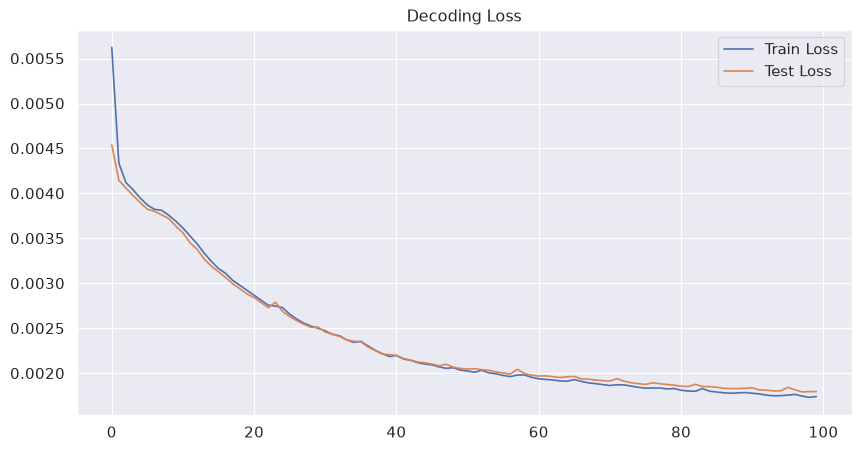

In [35]:
plt.figure(figsize=(10, 5), dpi=100)
plt.title('Decoding Loss')

plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')

plt.legend()
plt.show()

In [36]:
torch.save(model.encoder.state_dict(), models_dir / encoder_name)
torch.save(model.decoder.state_dict(), models_dir / decoder_name)